In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Dataset generation
# -----------------------------
class CircleDataset(Dataset):
    def __init__(self, num_samples=1000, img_size=28):
        self.num_samples = num_samples
        self.img_size = img_size
        self.data = []
        self.params = []
        for _ in range(num_samples):
            x = np.random.uniform(5, img_size-5)
            y = np.random.uniform(5, img_size-5)
            r = np.random.uniform(2, 8)
            self.params.append([x/img_size, y/img_size, r/img_size])  # normalize
            img = np.zeros((img_size, img_size), dtype=np.float32)
            for i in range(img_size):
                for j in range(img_size):
                    if (i - y)**2 + (j - x)**2 <= r**2:
                        img[i, j] = 1.0
            self.data.append(img)
        self.data = np.array(self.data)[:, None, :, :]  # add channel dim
        self.params = np.array(self.params, dtype=np.float32)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx]), torch.tensor(self.params[idx])

# Create dataset and dataloader
dataset = CircleDataset(num_samples=2000, img_size=28)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# -----------------------------
# 2. Encoder network
# -----------------------------
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  # 14x14 -> 7x7
            nn.ReLU()
        )
        self.fc = nn.Linear(32*7*7, 3)  # output x, y, r

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = torch.sigmoid(self.fc(x))  # normalized between 0-1
        return x

# -----------------------------
# 3. Decoder network
# -----------------------------
class Decoder(nn.Module):
    def __init__(self, img_size=28):
        super().__init__()
        self.img_size = img_size
        self.fc = nn.Linear(3, 32*7*7)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, params):
        x = self.fc(params)
        x = x.view(x.size(0), 32, 7, 7)
        x = self.deconv(x)
        return x

# -----------------------------
# 4. Autoencoder and training
# -----------------------------
encoder = Encoder()
decoder = Decoder(img_size=28)

optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)
criterion = nn.MSELoss()

# Training loop
encoder = Encoder()
optimizer = optim.Adam(encoder.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# Supervised training on parameters
for epoch in range(30):
    total_loss = 0
    for imgs, params in dataloader:
        optimizer.zero_grad()
        pred_params = encoder(imgs)
        loss = criterion(pred_params, params)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Param Loss: {total_loss/len(dataloader):.4f}")



Epoch 1, Param Loss: 0.0133
Epoch 2, Param Loss: 0.0026
Epoch 3, Param Loss: 0.0009
Epoch 4, Param Loss: 0.0005
Epoch 5, Param Loss: 0.0004
Epoch 6, Param Loss: 0.0003
Epoch 7, Param Loss: 0.0002
Epoch 8, Param Loss: 0.0002
Epoch 9, Param Loss: 0.0002
Epoch 10, Param Loss: 0.0002
Epoch 11, Param Loss: 0.0001
Epoch 12, Param Loss: 0.0001
Epoch 13, Param Loss: 0.0001
Epoch 14, Param Loss: 0.0001
Epoch 15, Param Loss: 0.0001
Epoch 16, Param Loss: 0.0001
Epoch 17, Param Loss: 0.0001
Epoch 18, Param Loss: 0.0001
Epoch 19, Param Loss: 0.0001
Epoch 20, Param Loss: 0.0001
Epoch 21, Param Loss: 0.0001
Epoch 22, Param Loss: 0.0001
Epoch 23, Param Loss: 0.0001
Epoch 24, Param Loss: 0.0001
Epoch 25, Param Loss: 0.0001
Epoch 26, Param Loss: 0.0001
Epoch 27, Param Loss: 0.0001
Epoch 28, Param Loss: 0.0001
Epoch 29, Param Loss: 0.0001
Epoch 30, Param Loss: 0.0001


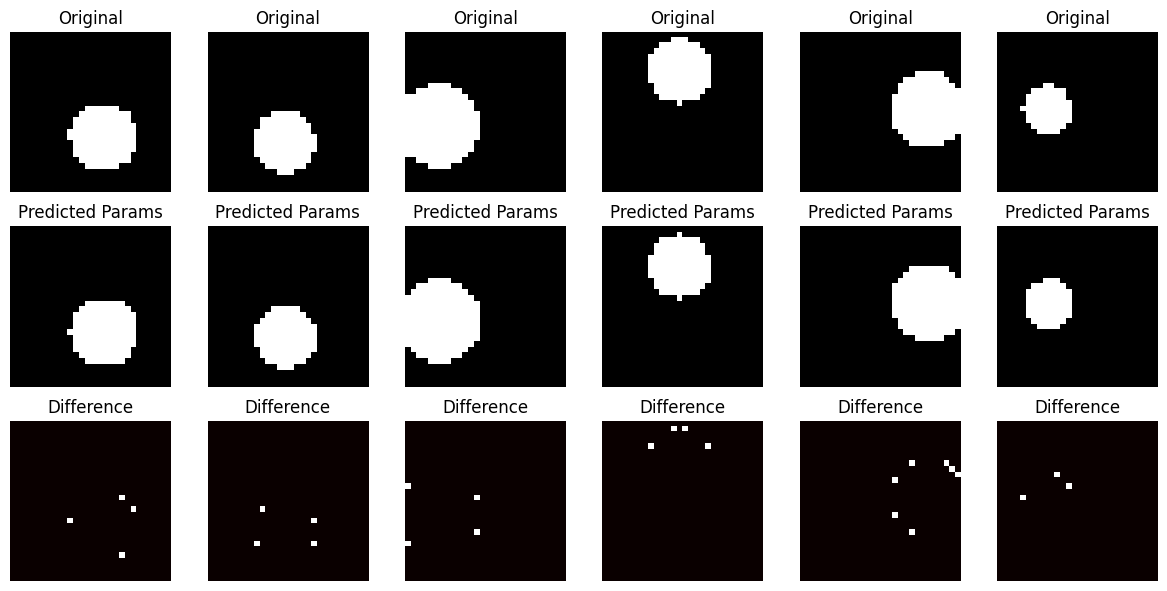

In [3]:
# Function to generate circle image from predicted parameters
def generate_circle_image(params, img_size=28):
    x = params[0] * img_size
    y = params[1] * img_size
    r = params[2] * img_size
    img = np.zeros((img_size, img_size), dtype=np.float32)
    for i in range(img_size):
        for j in range(img_size):
            if (i - y)**2 + (j - x)**2 <= r**2:
                img[i, j] = 1.0
    return img

# Take a batch of images
imgs, true_params = next(iter(dataloader))
pred_params = encoder(imgs).detach().numpy()
true_params = true_params.numpy()

# Visualize
num_to_show = 6
fig, axes = plt.subplots(3, num_to_show, figsize=(12,6))
for i in range(num_to_show):
    # Original image
    axes[0,i].imshow(imgs[i,0], cmap='gray')
    axes[0,i].axis('off')
    axes[0,i].set_title("Original")

    # Reconstructed image from predicted parameters
    recon_img = generate_circle_image(pred_params[i])
    axes[1,i].imshow(recon_img, cmap='gray')
    axes[1,i].axis('off')
    axes[1,i].set_title("Predicted Params")

    # Difference
    diff_img = np.abs(imgs[i,0].numpy() - recon_img)
    axes[2,i].imshow(diff_img, cmap='hot')
    axes[2,i].axis('off')
    axes[2,i].set_title("Difference")
plt.tight_layout()
plt.show()